# Chapter 62 — Multi-Head Attention

## Learning goals

By the end of this chapter, you should be able to:

- Explain why several attention heads can represent several matching patterns.

- Distinguish embedding dimension, number of heads, and head size.

- Build independently parameterized heads with `torch.nn.ModuleList`.

- Interpret attention weights shaped `[batch, heads, context, context]`.

- Concatenate head outputs along the feature dimension.

- Project concatenated features back to the embedding dimension.

- Explain when the embedding dimension must divide evenly by the number of heads.

- Verify that multi-head attention preserves batch size and context length.

- Explain why a `ModuleList` implementation is clear but not fully vectorized.

- Confirm that causal masking and batch independence hold for every head.


## Several views of the same sequence

Chapter 61 computed one attention pattern for every sequence in a batch.

One head has one set of query, key, and value projections, so it learns one family of matching and mixing rules.

**Multi-head attention** gives several heads the same input while giving each head separate projection parameters.

Different heads can therefore learn different useful relationships, such as local context, repeated tokens, or separators.

Those roles are examples rather than assignments supplied by a programmer.

Training determines whether the heads specialize and what patterns they learn.


## Shape notation

We will use these symbols throughout the chapter:

- `B` is batch size.

- `T` is context length.

- `C` is embedding dimension.

- `H` is number of heads.

- `D` is head size in this equal-head design.

Each head maps input `[B, T, C]` to output `[B, T, D]`.

Concatenating `H` head outputs produces `[B, T, H × D]`, and an output projection maps those features to `[B, T, C]`.


## Equal head sizes and divisibility

A standard design chooses `D = C / H`, making the concatenated width `H × D` equal to `C`.

That design requires `C` to divide evenly by `H`.

The divisibility rule is not a mathematical requirement of all possible multi-head modules because an output projection could accept any concatenated width.

It is a requirement of the equal split used here and in common transformer configurations.


The first code cell creates a deterministic batch and computes the equal head size.


In [1]:
import torch

device = "cpu"
torch.manual_seed(62)

batch_size = 2
context_length = 4
embedding_dimension = 8
number_of_heads = 4

if embedding_dimension % number_of_heads != 0:
    raise ValueError("embedding dimension must divide evenly by head count.")

head_size = embedding_dimension // number_of_heads
input_vectors = torch.randn(
    batch_size,
    context_length,
    embedding_dimension,
    device=device,
)

print("device:", device)
print("input shape:", input_vectors.shape)
print("number of heads:", number_of_heads)
print("head size:", head_size)
print("concatenated width:", number_of_heads * head_size)

device: cpu
input shape: torch.Size([2, 4, 8])
number of heads: 4
head size: 2
concatenated width: 8


The input has shape `[2, 4, 8]`, while each of the four heads will produce `[2, 4, 2]`.

Four feature groups of width `2` concatenate back to width `8`.


## One inspectable causal head

The single-head module below follows Chapter 60 but also exposes its attention weights for inspection.

Its Boolean causal mask has a leading singleton batch axis and broadcasts across every input sequence.


In [2]:
import math


class SingleHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    head_size: int
    context_length: int
    query_projection: torch.nn.Linear
    key_projection: torch.nn.Linear
    value_projection: torch.nn.Linear
    causal_mask: torch.Tensor

    def __init__(
        self,
        embedding_dimension: int,
        head_size: int,
        context_length: int,
    ) -> None:
        super().__init__()

        if embedding_dimension < 1 or head_size < 1 or context_length < 1:
            raise ValueError("all dimensions must be positive.")

        self.embedding_dimension = embedding_dimension
        self.head_size = head_size
        self.context_length = context_length
        self.query_projection = torch.nn.Linear(
            embedding_dimension, head_size, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, head_size, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, head_size, bias=False
        )
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(1, context_length, context_length, dtype=torch.bool)),
        )

    def forward_with_weights(
        self, input_vectors: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if input_vectors.ndim != 3:
            raise ValueError("input must have shape [batch, context, embedding].")

        if input_vectors.shape[-1] != self.embedding_dimension:
            raise ValueError("input embedding dimension is incorrect.")

        current_context_length = input_vectors.shape[-2]
        if current_context_length > self.context_length:
            raise ValueError("input exceeds the configured context length.")

        queries = self.query_projection(input_vectors)
        keys = self.key_projection(input_vectors)
        values = self.value_projection(input_vectors)
        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_size)
        allowed = self.causal_mask[:, :current_context_length, :current_context_length]
        weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)

        return weights @ values, weights

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        output, _ = self.forward_with_weights(input_vectors)
        return output

One head returns output `[B, T, D]` and weights `[B, T, T]`.

The ordinary `forward` method returns only the output, while the teaching method keeps the probability table available.


## ModuleList registers independent heads

`torch.nn.ModuleList` stores submodules while registering their parameters and buffers with the parent model.

Each list entry is a separate module with independently initialized query, key, and value weights.

A plain Python list would not register those submodules for optimization, serialization, or device movement.


In [3]:
torch.manual_seed(62)
attention_heads = torch.nn.ModuleList(
    [
        SingleHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            head_size=head_size,
            context_length=context_length,
        )
        for _ in range(number_of_heads)
    ]
).to(device)

head_outputs = []
head_attention_weights = []
for head_index, attention_head in enumerate(attention_heads):
    head_output, head_weights = attention_head.forward_with_weights(input_vectors)
    head_outputs.append(head_output)
    head_attention_weights.append(head_weights)
    print(
        f"head {head_index}: output {tuple(head_output.shape)}, "
        f"weights {tuple(head_weights.shape)}"
    )

stacked_attention_weights = torch.stack(head_attention_weights, dim=1)
print("stacked attention weight shape:", stacked_attention_weights.shape)
print("registered parameter tensors:", len(list(attention_heads.parameters())))

head 0: output (2, 4, 2), weights (2, 4, 4)
head 1: output (2, 4, 2), weights (2, 4, 4)
head 2: output (2, 4, 2), weights (2, 4, 4)
head 3: output (2, 4, 2), weights (2, 4, 4)
stacked attention weight shape: torch.Size([2, 4, 4, 4])
registered parameter tensors: 12


The stacked weights have shape `[B, H, T, T]`, or `[2, 4, 4, 4]`.

The new head axis selects one independently parameterized attention table.

Each of the four heads contributes three registered parameter tensors, one for each projection.


## Concatenate features, not examples or positions

Every head describes the same batch items and receiving positions with a different feature vector.

Concatenation must therefore use the last feature dimension.

Joining four `[2, 4, 2]` outputs along that dimension produces `[2, 4, 8]`.


In [4]:
concatenated_head_outputs = torch.cat(head_outputs, dim=-1)
output_projection = torch.nn.Linear(
    number_of_heads * head_size,
    embedding_dimension,
).to(device)
projected_output = output_projection(concatenated_head_outputs)

print("input shape:", input_vectors.shape)
for head_index, head_output in enumerate(head_outputs):
    print(f"head {head_index} output shape:", head_output.shape)
print("concatenated shape:", concatenated_head_outputs.shape)
print("projected shape:", projected_output.shape)

input shape: torch.Size([2, 4, 8])
head 0 output shape: torch.Size([2, 4, 2])
head 1 output shape: torch.Size([2, 4, 2])
head 2 output shape: torch.Size([2, 4, 2])
head 3 output shape: torch.Size([2, 4, 2])
concatenated shape: torch.Size([2, 4, 8])
projected shape: torch.Size([2, 4, 8])


Concatenation preserves `B` and `T` and joins only the `D` features from each head.

The output projection mixes information across those head feature groups and returns width `C`.

Its purpose is learned feature mixing, even when `H × D` already equals `C`.


## A reusable multi-head module

The parent module owns the heads and the output projection.

Its inspection method stacks weights on an explicit head axis and returns the concatenated features alongside the final result.


In [5]:
class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_heads: int
    head_size: int
    context_length: int
    attention_heads: torch.nn.ModuleList
    output_projection: torch.nn.Linear

    def __init__(
        self,
        embedding_dimension: int,
        number_of_heads: int,
        context_length: int,
    ) -> None:
        super().__init__()

        if embedding_dimension < 1 or number_of_heads < 1 or context_length < 1:
            raise ValueError("all dimensions and the head count must be positive.")

        if embedding_dimension % number_of_heads != 0:
            raise ValueError(
                "embedding dimension must divide evenly by the head count "
                "for this equal-head design."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.head_size = embedding_dimension // number_of_heads
        self.context_length = context_length
        self.attention_heads = torch.nn.ModuleList(
            [
                SingleHeadCausalSelfAttention(
                    embedding_dimension=embedding_dimension,
                    head_size=self.head_size,
                    context_length=context_length,
                )
                for _ in range(number_of_heads)
            ]
        )
        self.output_projection = torch.nn.Linear(
            number_of_heads * self.head_size,
            embedding_dimension,
        )

    def forward_with_details(
        self, input_vectors: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        head_outputs = []
        head_weights = []
        for attention_head in self.attention_heads:
            output, weights = attention_head.forward_with_weights(input_vectors)
            head_outputs.append(output)
            head_weights.append(weights)

        concatenated = torch.cat(head_outputs, dim=-1)
        stacked_weights = torch.stack(head_weights, dim=1)
        projected = self.output_projection(concatenated)
        return projected, concatenated, stacked_weights

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        projected, _, _ = self.forward_with_details(input_vectors)
        return projected


torch.manual_seed(62)
multi_head_attention = MultiHeadCausalSelfAttention(
    embedding_dimension=embedding_dimension,
    number_of_heads=number_of_heads,
    context_length=context_length,
).to(device)

multi_head_output, concatenated_output, all_head_weights = (
    multi_head_attention.forward_with_details(input_vectors)
)

print("input shape:", input_vectors.shape)
print("all head weights shape:", all_head_weights.shape)
print("concatenated shape:", concatenated_output.shape)
print("projected output shape:", multi_head_output.shape)

input shape: torch.Size([2, 4, 8])
all head weights shape: torch.Size([2, 4, 4, 4])
concatenated shape: torch.Size([2, 4, 8])
projected output shape: torch.Size([2, 4, 8])


The complete module maps `[B, T, C]` back to `[B, T, C]`.

It preserves batch size and context length while temporarily adding head-specific feature and probability representations.


## Verify every head

Every attention row in every head must sum to `1`, and every future entry must be `0`.

Independently initialized heads should also produce different weight tables for this deterministic example.


In [6]:
causal_mask = torch.tril(
    torch.ones(context_length, context_length, dtype=torch.bool, device=device)
)
expanded_future_mask = (~causal_mask).view(1, 1, context_length, context_length)
expanded_future_mask = expanded_future_mask.expand_as(all_head_weights)
future_weights = all_head_weights[expanded_future_mask]
heads_zero_and_one_differ = not torch.allclose(
    all_head_weights[:, 0], all_head_weights[:, 1]
)

print("row sum shape:", all_head_weights.sum(dim=-1).shape)
print(
    "all rows sum to one:",
    torch.allclose(
        all_head_weights.sum(dim=-1),
        torch.ones(batch_size, number_of_heads, context_length),
    ),
)
print("all future weights are zero:", end=" ")
print(torch.all(future_weights == 0.0).item())
print("heads 0 and 1 have different weights:", heads_zero_and_one_differ)

row sum shape: torch.Size([2, 4, 4])
all rows sum to one: True
all future weights are zero: True
heads 0 and 1 have different weights: True


The causal constraints hold across both the batch and head axes.

Different initial projection weights create different attention patterns before any training occurs.

Different random patterns do not yet imply useful specialization, which must be learned from an objective and data.


The following single figure compares the four head distributions for the first batch item.


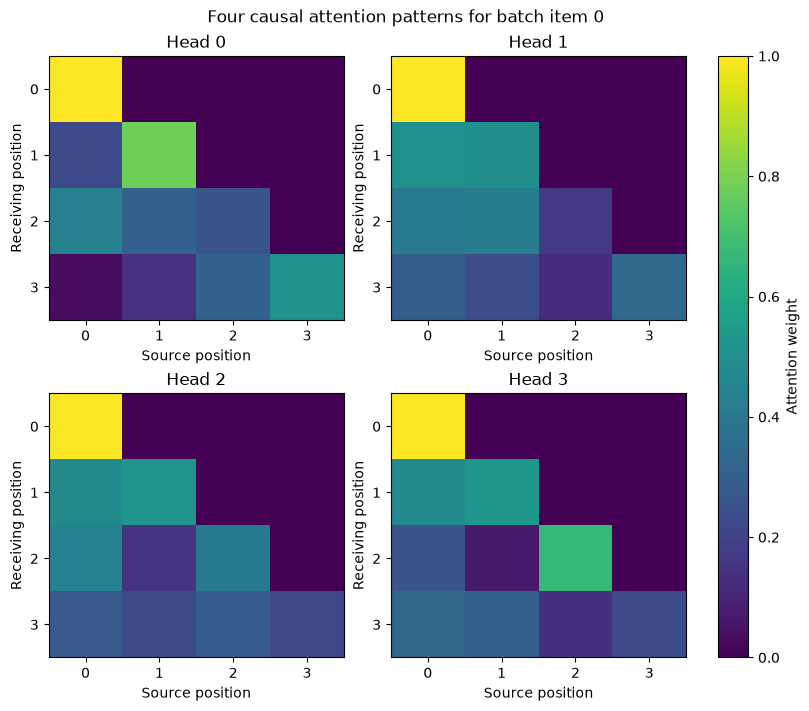

In [7]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
for head_index, axis in enumerate(axes.flat):
    image = axis.imshow(
        all_head_weights[0, head_index].detach(),
        aspect="auto",
        vmin=0.0,
        vmax=1.0,
    )
    axis.set_xticks(range(context_length))
    axis.set_yticks(range(context_length))
    axis.set_xlabel("Source position")
    axis.set_ylabel("Receiving position")
    axis.set_title(f"Head {head_index}")

figure.colorbar(image, ax=axes, label="Attention weight")
figure.suptitle("Four causal attention patterns for batch item 0")
plt.show()

All four panels share the causal zero pattern above the diagonal.

Their allowed weights differ because each head uses its own query and key projections.


## Parameter registration and count

The parent module must expose every head's projection weights through `model.parameters()`.

For `H × D = C` and bias-free query, key, and value projections, all heads together contain `3 × C × C` projection parameters.

The output projection adds `C × C` weights and `C` biases in this implementation.


In [8]:
def count_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


expected_parameter_count = (
    3 * embedding_dimension * embedding_dimension
    + embedding_dimension * embedding_dimension
    + embedding_dimension
)
actual_parameter_count = count_parameters(multi_head_attention)
parameter_names = [name for name, _ in multi_head_attention.named_parameters()]

print("expected parameter count:", expected_parameter_count)
print("actual parameter count:", actual_parameter_count)
print("counts match:", expected_parameter_count == actual_parameter_count)
print("first registered parameter:", parameter_names[0])
print("last registered parameter:", parameter_names[-1])
print("registered causal-mask buffers:", end=" ")
print(len(list(multi_head_attention.named_buffers())))

expected parameter count: 264
actual parameter count: 264
counts match: True
first registered parameter: attention_heads.0.query_projection.weight
last registered parameter: output_projection.bias
registered causal-mask buffers: 4


The matching count confirms that the parent module registered every head and the output projection.

This teaching design also stores one identical causal-mask buffer per head, which is clear but redundant.

A fused implementation can store one shared mask and compute all heads with larger combined tensors.


## Reject invalid equal splits

The constructor should reject configurations whose embedding width cannot be split into equal integer head sizes.

A small table makes valid and invalid choices visible without creating a failing notebook cell.


In [9]:
dimension_choices = [(8, 4), (12, 3), (12, 5), (16, 8), (10, 4)]

print("embedding | heads | valid equal split | head size")
print("-" * 50)
for candidate_embedding, candidate_heads in dimension_choices:
    is_valid = candidate_embedding % candidate_heads == 0
    candidate_head_size = candidate_embedding // candidate_heads if is_valid else None
    print(
        f"{candidate_embedding:>9} | {candidate_heads:>5} | "
        f"{str(is_valid):>17} | {candidate_head_size}"
    )

try:
    MultiHeadCausalSelfAttention(
        embedding_dimension=10,
        number_of_heads=4,
        context_length=4,
    )
except ValueError as error:
    print("rejected invalid configuration:", error)

embedding | heads | valid equal split | head size
--------------------------------------------------
        8 |     4 |              True | 2
       12 |     3 |              True | 4
       12 |     5 |             False | None
       16 |     8 |              True | 2
       10 |     4 |             False | None
rejected invalid configuration: embedding dimension must divide evenly by the head count for this equal-head design.


A vector dimension must be a whole number, so `10 / 4` cannot define equal head sizes.

Rejecting the configuration early prevents ambiguous shapes later in the forward pass.


## Batch independence remains intact

Every head uses batched matrix multiplication from Chapter 61, so changing one input sequence must not affect another sequence's result.


In [10]:
changed_input_vectors = input_vectors.clone()
changed_input_vectors[1] = changed_input_vectors[1] + 10.0
changed_output = multi_head_attention(changed_input_vectors)

first_output_unchanged = torch.allclose(multi_head_output[0], changed_output[0])
second_output_changed = not torch.allclose(multi_head_output[1], changed_output[1])

print("first batch item output unchanged:", first_output_unchanged)
print("second batch item output changed:", second_output_changed)

first batch item output unchanged: True
second batch item output changed: True


The result confirms that adding heads introduces a head axis and more features without introducing cross-batch attention.


## Architectural parallelism and implementation efficiency

The heads are architecturally parallel because they all read the same input and no head consumes another head's output.

The simple `ModuleList` implementation still evaluates those independent heads with a Python loop.

Production implementations usually combine all query, key, and value projections into larger matrix operations and reshape an explicit head axis.

That vectorized organization is faster, but it implements the same conceptual operations:

1. Compute one attention result per head.

2. Join the head features.

3. Apply an output projection.


## Shape summary

| Tensor | Shape | Example |
|---|---:|---:|
| Input | `B × T × C` | `2 × 4 × 8` |
| One head output | `B × T × D` | `2 × 4 × 2` |
| One head weights | `B × T × T` | `2 × 4 × 4` |
| All head weights | `B × H × T × T` | `2 × 4 × 4 × 4` |
| Concatenated output | `B × T × (H × D)` | `2 × 4 × 8` |
| Projected output | `B × T × C` | `2 × 4 × 8` |

The batch and context axes remain unchanged from input to projected output.

Multi-head attention temporarily introduces multiple feature groups and multiple attention tables.


## Common mistakes

- **Treating heads as sequential layers:** all heads read the same input rather than feeding into one another.

- **Concatenating on the batch axis:** head features belong on the final feature axis.

- **Concatenating on the context axis:** multi-head attention must preserve sequence length.

- **Omitting the output projection:** concatenation collects features, while the projection learns to mix them.

- **Using a plain Python list:** unregistered head modules will be absent from the parent's parameters and state.

- **Overstating divisibility:** even division is required by this equal split, not by every conceivable multi-head design.

- **Calling the ModuleList loop computationally parallel:** the heads are independent, but this teaching code loops in Python.

- **Assuming random differences are learned roles:** useful specialization emerges only through training.


## Takeaways

- Each head has separate query, key, and value projections and can learn a different attention pattern.

- `ModuleList` registers the separate head modules with their parent.

- Head outputs concatenate along the final feature dimension.

- The output projection mixes head features and restores embedding width `C`.

- The equal split `D = C / H` requires `C` to divide evenly by `H`.

- Attention weights gain an explicit head axis with shape `[B, H, T, T]`.

- Multi-head attention preserves batch size, context length, causal masking, and batch independence.

> Multiple heads provide multiple learned views of the same input positions.


## What comes next

Attention lets positions gather information from other allowed positions.

The next chapter introduces the position-wise feedforward network, which transforms each position independently after attention has exchanged information across the sequence.
